# Runtime Detail

In [1]:
from pathlib import Path
from collections import Counter
import csv, json, os, random
import importlib.util, subprocess, sys
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

if importlib.util.find_spec('tensorflow') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow'])

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.22.0-rc0


# Load Dependencies

In [2]:
DATA_DIR = Path('dataset/load_energy_3class_daily')
OUTPUT_DIR = Path('outputs/basic_cnn_tensorflow_pearson_3class')
CLASS_NAMES = ('low activity', 'typical', 'peak dominant')
IMAGE_SIZE = (24, 24)
BATCH_SIZE = 128
EPOCHS = 30
print('Dataset:', DATA_DIR.resolve(), '| classes:', CLASS_NAMES)

Dataset: /Users/zendi.iklima/Documents/UTP/My Lectures/Intelligence System/Scripts/dataset/load_energy_3class_daily | classes: ('low activity', 'typical', 'peak dominant')


# Preparing Dataset

In [3]:
from src.image_dataset import load_image_splits

(x_train, y_train), (x_val, y_val), (x_test, y_test), (train_rows, val_rows, test_rows) = load_image_splits(
    data_dir=DATA_DIR,
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    seed=SEED,
    return_rows=True,
)
for name, labels in [('train', y_train), ('validasi', y_val), ('tes', y_test)]:
    print(name, len(labels), dict(Counter(labels)))

train 4031 {np.int32(1): 2825, np.int32(0): 580, np.int32(2): 626}
validasi 1345 {np.int32(1): 942, np.int32(2): 209, np.int32(0): 194}
tes 1344 {np.int32(1): 942, np.int32(0): 193, np.int32(2): 209}


## Rescaling

In [4]:
AUTOTUNE = tf.data.AUTOTUNE
train_data = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train)
).shuffle(
    len(y_train), 
    seed=SEED
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_data = tf.data.Dataset.from_tensor_slices(
    (x_val, y_val)
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

evaluation_data = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print('Batches:', {'train': len(train_data), 'validasi': len(val_data), 'tes': len(evaluation_data)})

Batches: {'train': 32, 'validasi': 11, 'tes': 11}


# Preparing Architecture

In [5]:
model = keras.Sequential([
    keras.Input(shape=(*IMAGE_SIZE, 3)),
    layers.Conv2D(filters=64, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=128, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=256, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Flatten(), layers.Dense(32, activation='relu'),
    layers.Dense(len(CLASS_NAMES), activation='softmax'),
], name='basic_cnn_pearson_rgb')
model.summary()

Model: "basic_cnn_pearson_rgb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 22, 22, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 1, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 380,163 (1.45 MB)

 Trainable params: 379,651 (1.45 MB)

 Non-trainable params: 512 (2.00 KB)

In [6]:
# !pip install pydot
!pip install pydot

In [7]:
tf.keras.utils.plot_model(
    model,
    to_file="model.png",
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=True,
    dpi=96,
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


# Training...

In [8]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

In [9]:
%%time
print("Training ...")

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=6, 
    restore_best_weights=True
)

history = model.fit(
    train_data, 
    validation_data=val_data, 
    epochs=EPOCHS, 
    verbose=2, 
    callbacks=[early_stop]
)

Training ...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


CPU times: user 2min 41s, sys: 4.63 s, total: 2min 46s
Wall time: 23.6 s


# PLOTs and Evaluation

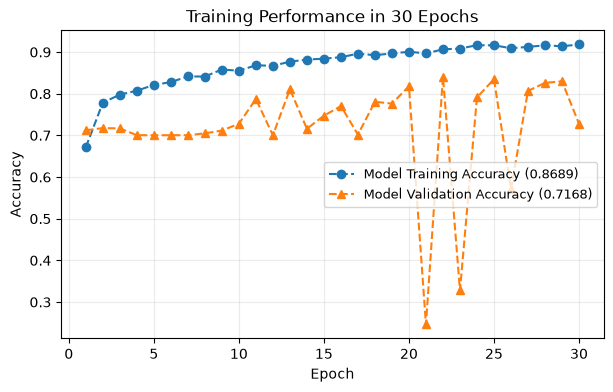

In [10]:
epochs_completed = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(7, 4))
plt.plot(
  epochs_completed,
  history.history['accuracy'],
  'o--',
  label='Model Training Accuracy ({:.4f})'.format(np.average( history.history['accuracy'] ))
)
plt.plot(
  epochs_completed,
  history.history['val_accuracy'],
  '^--',
  label='Model Validation Accuracy ({:.4f})'.format(np.average( history.history['val_accuracy'] ))
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Performance in %d Epochs' % len(history.history['accuracy']))
plt.legend(loc=5, prop={'size': 9})
plt.grid(alpha=0.25)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / 'model_acc.png', dpi=180, bbox_inches='tight')
plt.show()

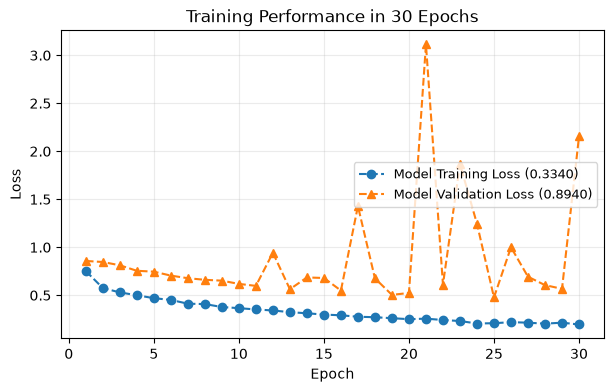

In [11]:
epochs_completed = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(7, 4))
plt.plot(
  epochs_completed,
  history.history['loss'],
  'o--',
  label='Model Training Loss ({:.4f})'.format(np.average( history.history['loss'] ))
)

plt.plot(
  epochs_completed,
  history.history['val_loss'],
  '^--',
  label='Model Validation Loss ({:.4f})'.format(np.average( history.history['val_loss'] ))
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Performance in %d Epochs' % len(history.history['loss']))
plt.legend(loc=5, prop={'size': 9})
plt.grid(alpha=0.25)


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / 'model_loss.png', dpi=180, bbox_inches='tight')
plt.show()

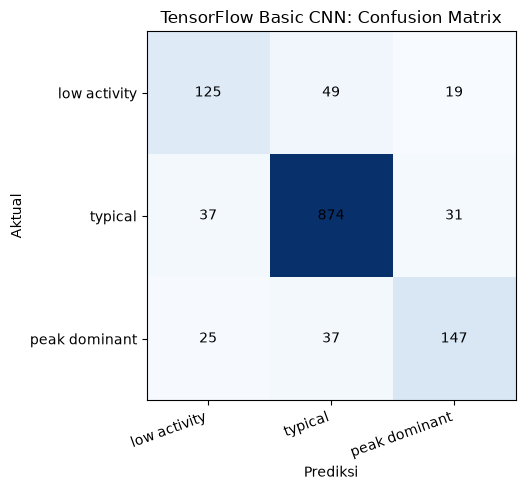

In [12]:
probabilities = model.predict(
    x_test, 
    batch_size=BATCH_SIZE, 
    verbose=0
)

y_pred = probabilities.argmax(axis=1)

cm = np.zeros((3, 3), dtype=np.int64)

for actual, predicted in zip(y_test, y_pred): cm[actual, predicted] += 1

fig, ax = plt.subplots(figsize=(6, 5)); ax.imshow(cm, cmap='Blues')

ax.set(
    xticks=range(3), 
    yticks=range(3), 
    xticklabels=CLASS_NAMES, 
    yticklabels=CLASS_NAMES, 
    xlabel='Prediksi', 
    ylabel='Aktual', 
    title='TensorFlow Basic CNN: Confusion Matrix'
)

for i in range(3):
    for j in range(3): ax.text(j, i, str(cm[i, j]), ha='center', va='center')

plt.setp(
    ax.get_xticklabels(), 
    rotation=20, 
    ha='right'
)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=180)
plt.show()


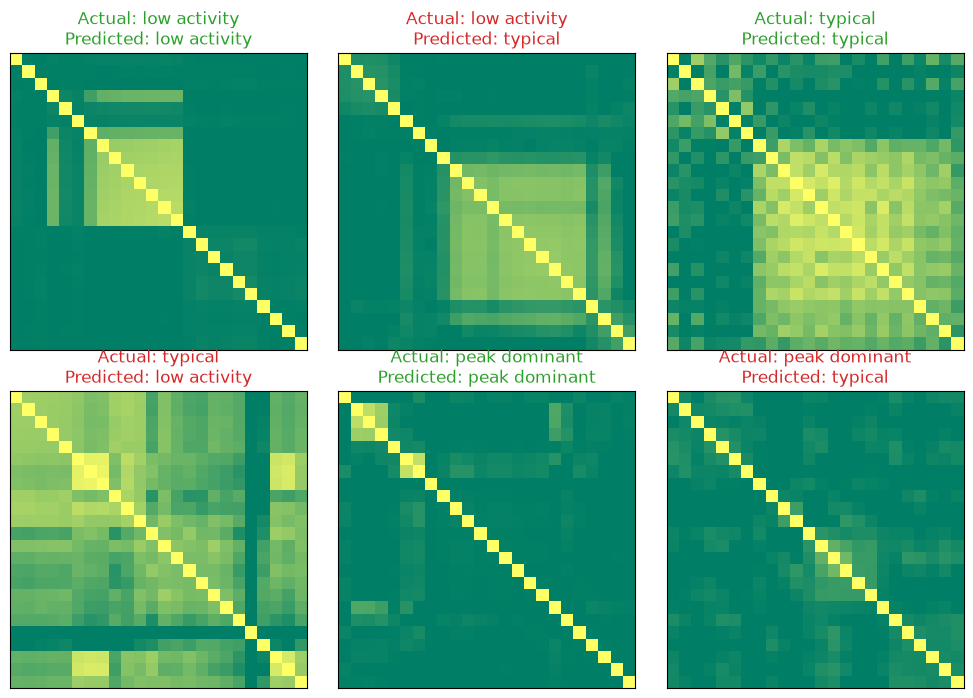

Test sample: BN138_2020-01-27
Actual: typical | Predicted: typical
Probabilities: {'low activity': np.float32(0.005), 'typical': np.float32(0.987), 'peak dominant': np.float32(0.008)}


In [13]:
from src.image_cnn_evaluation import plot_test_examples, predict_one

fig = plot_test_examples(
    test_rows, y_pred, DATA_DIR, OUTPUT_DIR / 'test_examples.png'
)
plt.show()

actual, predicted, probabilities = predict_one(
    model, x_test, y_test, index=0
)
print('Test sample:', test_rows[0]['sample_id'])
print('Actual:', CLASS_NAMES[actual], '| Predicted:', CLASS_NAMES[predicted])
print('Probabilities:', dict(zip(CLASS_NAMES, probabilities.round(3))))

In [14]:
from src.image_cnn_artifacts import save_run

test_probabilities = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
test_predicted = test_probabilities.argmax(axis=1)
matrix = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=np.int64)
for actual, predicted in zip(y_test, test_predicted):
    matrix[actual, predicted] += 1
precision = np.diag(matrix) / np.maximum(matrix.sum(axis=0), 1)
recall = np.diag(matrix) / np.maximum(matrix.sum(axis=1), 1)
f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-12)
test_loss, test_accuracy = model.evaluate(evaluation_data, verbose=0)
best_epoch = int(np.argmin(history.history['val_loss']) + 1)
normalization = {'method': 'RGB / 255.0', 'input_shape': [*IMAGE_SIZE, 3]}
metrics = {
    'framework': 'TensorFlow 2 / Keras',
    'architecture': model.name,
    'class_names': list(CLASS_NAMES),
    'split': 'profile_stratified_60_20_20_seed_42',
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
    'test_macro_f1': float(f1.mean()),
    'confusion_matrix': matrix.tolist(),
    'per_class': {
        CLASS_NAMES[i]: {
            'precision': float(precision[i]), 'recall': float(recall[i]),
            'f1': float(f1[i]), 'support': int(matrix[i].sum())
        } for i in range(len(CLASS_NAMES))
    },
}

report = save_run(
    OUTPUT_DIR, model, history, metrics,
    (train_rows, val_rows, test_rows), normalization, SEED, best_epoch
)
print('Saved to:', OUTPUT_DIR.resolve())
print('Test accuracy:', round(report['test_accuracy'], 3),
      '| Test macro-F1:', round(report['test_macro_f1'], 3))

Saved to: /Users/zendi.iklima/Documents/UTP/My Lectures/Intelligence System/Scripts/outputs/basic_cnn_tensorflow_pearson_3class
Test accuracy: 0.853 | Test macro-F1: 0.767
